## Goal

Understand the behavioral patterns, distributions, relationships, and potential biases in users' interactions with movies.

In [2]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load / Prepare Data
users_df = pd.read_csv('../data/raw/users.dat', sep='::', engine='python', header=None, names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code'])
ratings_df = pd.read_csv('../data/raw/ratings.dat', sep='::', engine='python', header=None, names=['UserID', 'MovieID', 'Rating', 'Timestamp'])
movies_df = pd.read_csv('../data/raw/movies.dat', sep='::', engine='python', header=None, names=['MovieID', 'Title', 'Genres'], encoding='latin-1')

In [4]:
ratings_df['TimestampDate'] = pd.to_datetime(ratings_df['Timestamp'], unit='s')

In [5]:
ratings_df['YearMonth'] = ratings_df['TimestampDate'].dt.to_period('M')

In [8]:
# User Analysis
# - User Demographics
users_df['Gender'].value_counts(normalize=True) * 100

Gender
M    71.705298
F    28.294702
Name: proportion, dtype: float64

- Age is chosen from the following ranges:

	*  1:  "Under 18"
	* 18:  "18-24"
	* 25:  "25-34"
	* 35:  "35-44"
	* 45:  "45-49"
	* 50:  "50-55"
	* 56:  "56+"

In [9]:
users_df['Age'].value_counts(normalize=True) * 100

Age
25    34.701987
35    19.751656
18    18.261589
45     9.105960
50     8.211921
56     6.291391
1      3.675497
Name: proportion, dtype: float64

- Occupation is chosen from the following choices:

	*  0:  "other" or not specified
	*  1:  "academic/educator"
	*  2:  "artist"
	*  3:  "clerical/admin"
	*  4:  "college/grad student"
	*  5:  "customer service"
	*  6:  "doctor/health care"
	*  7:  "executive/managerial"
	*  8:  "farmer"
	*  9:  "homemaker"
	* 10:  "K-12 student"
	* 11:  "lawyer"
	* 12:  "programmer"
	* 13:  "retired"
	* 14:  "sales/marketing"
	* 15:  "scientist"
	* 16:  "self-employed"
	* 17:  "technician/engineer"
	* 18:  "tradesman/craftsman"
	* 19:  "unemployed"
	* 20:  "writer"

In [10]:
users_df['Occupation'].value_counts(normalize=True) * 100

Occupation
4     12.566225
0     11.771523
7     11.241722
1      8.741722
17     8.311258
12     6.423841
14     5.000000
20     4.652318
2      4.420530
16     3.990066
6      3.907285
10     3.228477
3      2.864238
15     2.384106
13     2.350993
11     2.135762
5      1.854305
9      1.523179
19     1.192053
18     1.158940
8      0.281457
Name: proportion, dtype: float64

In [11]:
# - User Activity
user_rating_count = ratings_df.groupby('UserID')['Rating'].size()
user_average_rating = ratings_df.groupby('UserID')['Rating'].mean()
user_rating_std = ratings_df.groupby('UserID')['Rating'].std()
print(f"Rating Count: {user_rating_count}")
print(f"Rating Average: {user_average_rating}")
print(f"Rating STD: {user_rating_std}")

Rating Count: UserID
1        53
2       129
3        51
4        21
5       198
       ... 
6036    888
6037    202
6038     20
6039    123
6040    341
Name: Rating, Length: 6040, dtype: int64
Rating Average: UserID
1       4.188679
2       3.713178
3       3.901961
4       4.190476
5       3.146465
          ...   
6036    3.302928
6037    3.717822
6038    3.800000
6039    3.878049
6040    3.577713
Name: Rating, Length: 6040, dtype: float64
Rating STD: UserID
1       0.680967
2       1.001513
3       0.984985
4       1.077917
5       1.132699
          ...   
6036    1.023684
6037    0.877910
6038    1.105013
6039    0.730881
6040    1.179719
Name: Rating, Length: 6040, dtype: float64


In [12]:
user_rating_count.describe()

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
Name: Rating, dtype: float64

In [13]:
user_average_rating.describe()

count    6040.000000
mean        3.702705
std         0.429622
min         1.015385
25%         3.444444
50%         3.735294
75%         4.000000
max         4.962963
Name: Rating, dtype: float64

In [14]:
user_rating_std.describe()

count    6040.000000
mean        1.010186
std         0.203769
min         0.124035
25%         0.869130
50%         0.997096
75%         1.134735
max         1.861354
Name: Rating, dtype: float64

In [15]:
# Movie Analysis
movie_rating_count = ratings_df.groupby('MovieID')['Rating'].size()
movie_average_rating = ratings_df.groupby('MovieID')['Rating'].mean()
movie_rating_count.describe(), movie_average_rating.describe()

(count    3706.000000
 mean      269.889099
 std       384.047838
 min         1.000000
 25%        33.000000
 50%       123.500000
 75%       350.000000
 max      3428.000000
 Name: Rating, dtype: float64,
 count    3706.000000
 mean        3.238892
 std         0.672925
 min         1.000000
 25%         2.822705
 50%         3.331546
 75%         3.740741
 max         5.000000
 Name: Rating, dtype: float64)

In [22]:
movies_df['Genres'].head(10), movies_df['Genres'].nunique()

(0     Animation|Children's|Comedy
 1    Adventure|Children's|Fantasy
 2                  Comedy|Romance
 3                    Comedy|Drama
 4                          Comedy
 5           Action|Crime|Thriller
 6                  Comedy|Romance
 7            Adventure|Children's
 8                          Action
 9       Action|Adventure|Thriller
 Name: Genres, dtype: str,
 301)

In [23]:
movies_df['ReleaseYear'] = movies_df['Title'].str.extract(r'\((\d{4})\)')

In [24]:
movies_df['ReleaseYear'] = pd.to_numeric(movies_df['ReleaseYear'])

In [25]:
movies_df['ReleaseYear'].describe()

count    3883.000000
mean     1986.066959
std        16.895690
min      1919.000000
25%      1982.000000
50%      1994.000000
75%      1997.000000
max      2000.000000
Name: ReleaseYear, dtype: float64

In [47]:
# Genre Analysis
genres_exploded = movies_df['Genres'].str.split('|').explode()
genres_exploded.value_counts(normalize=True) * 100

Genres
Drama          25.015605
Comedy         18.726592
Action          7.849563
Thriller        7.677903
Romance         7.350187
Horror          5.352684
Adventure       4.416355
Sci-Fi          4.307116
Children's      3.916979
Crime           3.292759
War             2.231586
Documentary     1.981898
Musical         1.779026
Mystery         1.654182
Animation       1.638577
Fantasy         1.061174
Western         1.061174
Film-Noir       0.686642
Name: proportion, dtype: float64

Drama is the most represented genre in the movie catalog, followed by Comedy.

In [48]:
genres_exploded.nunique()

18

In [55]:
movie_genre_count = movies_df['Genres'].str.split('|').str.len()
movie_genre_count.describe()

count    3883.000000
mean        1.650270
std         0.804589
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         6.000000
Name: Genres, dtype: float64

In [58]:
movie_genre_count.value_counts(normalize=True) * 100

Genres
1    52.150399
2    34.045841
3    10.842132
4     2.575328
5     0.360546
6     0.025753
Name: proportion, dtype: float64

In [61]:
# Interaction Analysis
user_movie_df = ratings_df.merge(
    movies_df[['MovieID', 'Title', 'Genres']],
    on='MovieID',
    how='left'
)
user_movie_df.head(10)

,UserID,MovieID,Rating,Timestamp,TimestampDate,YearMonth,Title,Genres
0,1,1193,5,978300760,2000-12-31 22:12:40,2000-12,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,2000-12-31 22:35:09,2000-12,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,2000-12-31 22:32:48,2000-12,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,2000-12-31 22:04:35,2000-12,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,2001-01-06 23:38:11,2001-01,"Bug's Life, A (1998)",Animation|Children's|Comedy
5,1,1197,3,978302268,2000-12-31 22:37:48,2000-12,"Princess Bride, The (1987)",Action|Adventure|Comedy|Romance
6,1,1287,5,978302039,2000-12-31 22:33:59,2000-12,Ben-Hur (1959),Action|Adventure|Drama
7,1,2804,5,978300719,2000-12-31 22:11:59,2000-12,"Christmas Story, A (1983)",Comedy|Drama
8,1,594,4,978302268,2000-12-31 22:37:48,2000-12,Snow White and the Seven Dwarfs (1937),Animation|Children's|Musical
9,1,919,4,978301368,2000-12-31 22:22:48,2000-12,"Wizard of Oz, The (1939)",Adventure|Children's|Drama|Musical


In [65]:
user_movie_genre_df = user_movie_df.copy()

user_movie_genre_df['Genres'] = (
    user_movie_genre_df['Genres']
    .str.split('|')
)

user_movie_genre_df = user_movie_genre_df.explode('Genres')
user_movie_genre_df.sample(10)

,UserID,MovieID,Rating,Timestamp,TimestampDate,YearMonth,Title,Genres
552241,3401,415,3,980116128,2001-01-21 22:28:48,2001-01,Another Stakeout (1993),Comedy
408128,2453,266,4,974190242,2000-11-14 08:24:02,2000-11,Legends of the Fall (1994),Western
724254,4337,1982,5,965346059,2000-08-03 23:40:59,2000-08,Halloween (1978),Horror
398193,2368,2442,4,974340451,2000-11-16 02:07:31,2000-11,Hilary and Jackie (1998),Drama
666974,4014,1969,4,965540063,2000-08-06 05:34:23,2000-08,Nightmare on Elm Street Part 2: Freddy's Reven...,Horror
266520,1616,2000,3,974729731,2000-11-20 14:15:31,2000-11,Lethal Weapon (1987),Crime
510217,3143,2692,4,969492603,2000-09-20 23:30:03,2000-09,Run Lola Run (Lola rennt) (1998),Crime
539330,3316,1097,4,967940415,2000-09-03 00:20:15,2000-09,E.T. the Extra-Terrestrial (1982),Sci-Fi
580575,3546,1573,4,967022372,2000-08-23 09:19:32,2000-08,Face/Off (1997),Thriller
983149,5938,2724,1,957212871,2000-05-01 20:27:51,2000-05,Runaway Bride (1999),Romance


In [68]:
user_genre_interactions = user_movie_genre_df.groupby(['UserID', 'Genres']).size()
user_genre_avg_rating = user_movie_genre_df.groupby(['UserID', 'Genres'])['Rating'].mean()

(UserID  Genres 
 4169    Drama      1071
 4277    Drama       724
 3618    Drama       672
 889     Drama       665
 4169    Comedy      657
                    ... 
 4775    Romance       1
         Fantasy       1
 3       Mystery       1
         Musical       1
 4       Crime         1
 Length: 93887, dtype: int64,
 UserID  Genres    
 1       Action        4.200000
         Adventure     4.000000
         Animation     4.111111
         Children's    4.250000
         Comedy        4.142857
                         ...   
 6040    Romance       3.488889
         Sci-Fi        3.473684
         Thriller      3.926829
         War           3.695652
         Western       4.000000
 Name: Rating, Length: 93887, dtype: float64)

In [75]:
genre_interaction_count = user_movie_genre_df.groupby('Genres').size().sort_values(ascending=False)
genre_interaction_count

Genres
Comedy         356580
Drama          354529
Action         257457
Thriller       189680
Sci-Fi         157294
Romance        147523
Adventure      133953
Crime           79541
Horror          76386
Children's      72186
War             68527
Animation       43293
Musical         41533
Mystery         40178
Fantasy         36301
Western         20683
Film-Noir       18261
Documentary      7910
dtype: int64

In [77]:
genre_average_rating = user_movie_genre_df.groupby('Genres')['Rating'].mean().sort_values(ascending=False)
genre_average_rating

Genres
Film-Noir      4.075188
Documentary    3.933123
War            3.893327
Drama          3.766332
Crime          3.708679
Animation      3.684868
Mystery        3.668102
Musical        3.665519
Western        3.637770
Romance        3.607465
Thriller       3.570466
Comedy         3.522099
Action         3.491185
Adventure      3.477257
Sci-Fi         3.466521
Fantasy        3.447371
Children's     3.422035
Horror         3.215013
Name: Rating, dtype: float64

In [83]:
user_movie_pairs = ratings_df[['UserID', 'MovieID']].drop_duplicates()

unique_interactions = len(user_movie_pairs)

total_possible_pairs = (
    ratings_df['UserID'].nunique()
    * ratings_df['MovieID'].nunique()
)

interaction_density = unique_interactions / total_possible_pairs
sparsity = 1 - interaction_density

In [84]:
interaction_density, sparsity

(0.044683625622312845, 0.9553163743776871)

In [87]:
ratings_df['UserID'].isin(users_df['UserID']).all(), ratings_df['MovieID'].isin(movies_df['MovieID']).all()

(np.True_, np.True_)

## Bias & Data Quality

### Observed Biases

- **Gender imbalance:** The user population is strongly skewed toward male users, with approximately 71.7% male and 28.3% female users. This imbalance may affect how well user preferences are represented across genders.

- **User activity imbalance:** User activity is strongly right-skewed. Most users have relatively few ratings, while a small number of highly active users contribute a large number of interactions. This means users do not provide the same amount of preference information.

- **Movie popularity imbalance:** Movie interactions are also strongly right-skewed. A small number of movies receive a large proportion of ratings, while many movies have relatively few interactions. This may introduce popularity bias into the recommendation process.

- **Rating distribution:** Ratings are concentrated toward higher values. Rating 4 is the most frequent value (34.89%), followed by ratings 3 (26.11%) and 5 (22.63%). This indicates that the observed ratings are generally positive rather than uniformly distributed across the rating scale.

- **Interaction sparsity:** The user–movie interaction space is highly sparse. Only approximately 4.26% of all possible user–movie pairs contain an observed interaction, leaving approximately 95.74% unobserved. This limited direct evidence can make personalized recommendation more challenging.

### Data Quality Checks

- **Missing values:** No missing values were detected in the Users, Ratings, or Movies datasets.

- **Duplicate records:** No exact duplicate rows were detected in the three datasets.

- **Referential integrity:** User and Movie identifiers in the Ratings dataset should correspond to valid records in the Users and Movies datasets.

### Engineering Implications

These observations do not necessarily indicate data errors. They describe characteristics of the collected dataset that should be considered during feature engineering, model development, and evaluation.

In particular, user activity imbalance, movie popularity bias, rating distribution, and high interaction sparsity may affect the quality and fairness of recommendations. These factors should therefore be considered when designing the recommendation strategy and evaluating its performance.

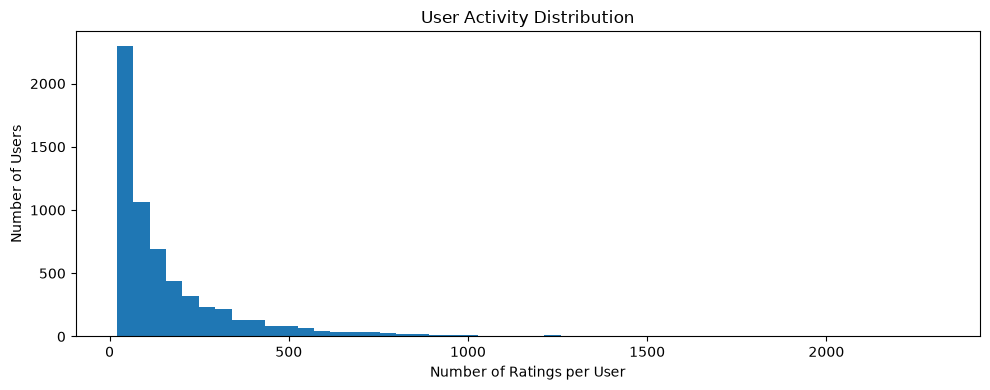

In [119]:
# Visualization
plt.figure(figsize=(10, 4))
plt.hist(user_rating_count, bins=50)
plt.title('User Activity Distribution')
plt.xlabel('Number of Ratings per User')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig('../figures/Sprint02/user_activity_distribution.png', dpi=300)
plt.show()
plt.close()

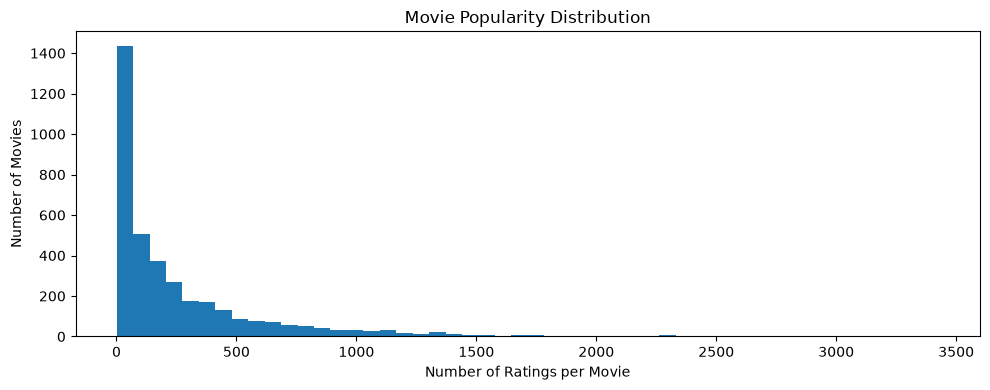

In [111]:
plt.figure(figsize=(10, 4))
plt.hist(movie_rating_count, bins=50)
plt.title('Movie Popularity Distribution')
plt.xlabel('Number of Ratings per Movie')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('../figures/Sprint02/movie_popularity_distribution.png', dpi=300)
plt.show()
plt.close()

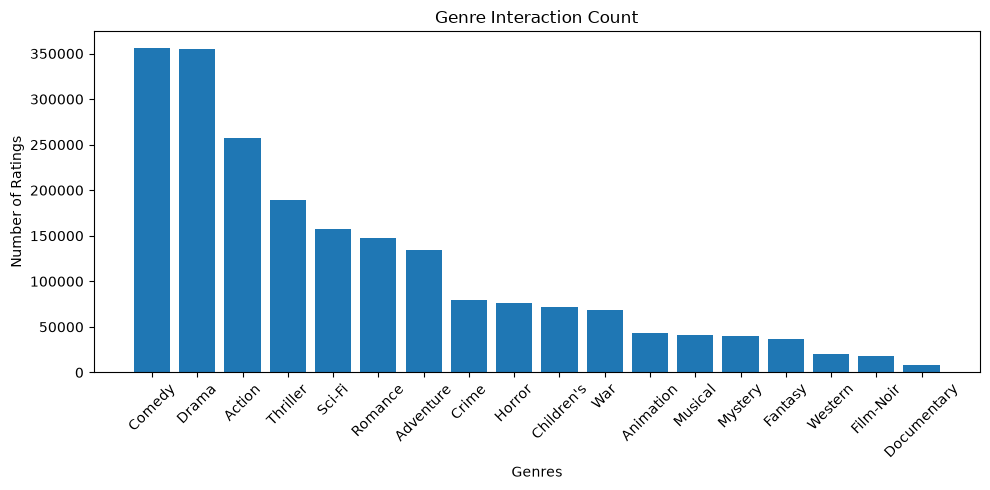

In [112]:
plt.figure(figsize=(10, 5))
plt.bar(genre_interaction_count.index, genre_interaction_count.values)
plt.title('Genre Interaction Count')
plt.xlabel('Genres')
plt.xticks(rotation=45)
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.savefig('../figures/Sprint02/genre_interaction_count.png', dpi=300)
plt.show()
plt.close()

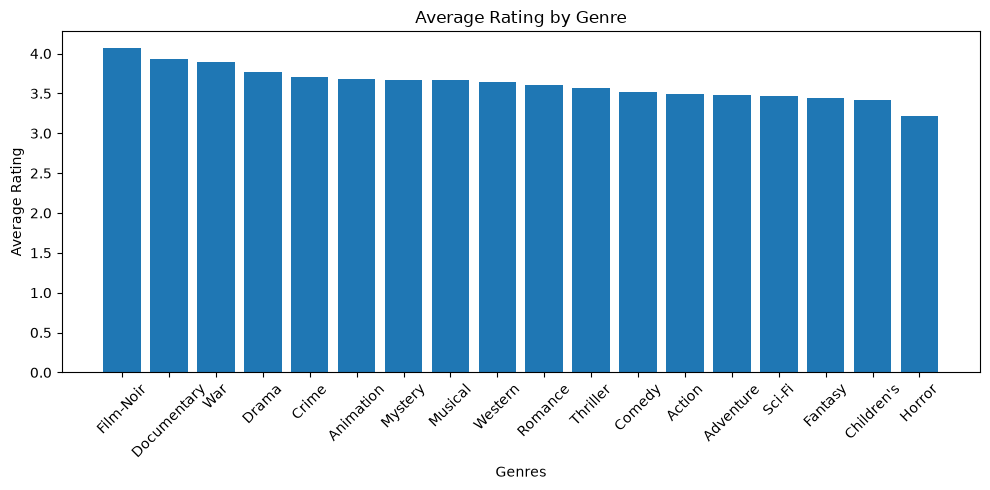

In [113]:
plt.figure(figsize=(10, 5))
plt.bar(genre_average_rating.index, genre_average_rating.values)
plt.title('Average Rating by Genre')
plt.xlabel('Genres')
plt.xticks(rotation=45)
plt.ylabel('Average Rating')
plt.tight_layout()
plt.savefig('../figures/Sprint02/average_rating_by_genre.png', dpi=300)
plt.show()
plt.close()

In [114]:
rating_distribution_by_genre = (
    user_movie_genre_df
    .groupby(['Genres', 'Rating'])
    .size()
)

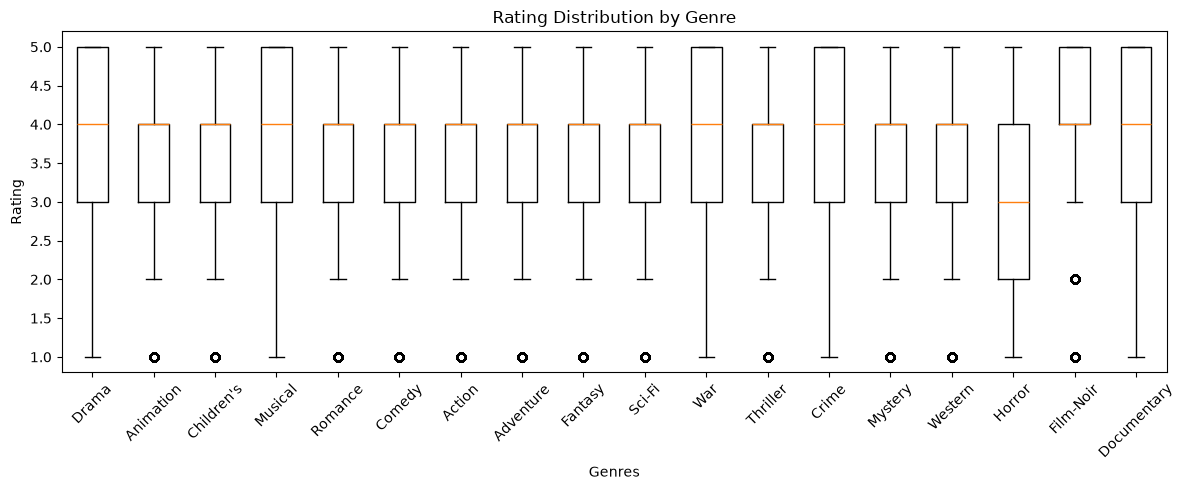

In [118]:
plt.figure(figsize=(12, 5))
plt.boxplot(
    [
        user_movie_genre_df.loc[
            user_movie_genre_df['Genres'] == genre,
            'Rating'
        ]
        for genre in user_movie_genre_df['Genres'].unique()
    ],
    tick_labels=user_movie_genre_df['Genres'].unique()
)
plt.title('Rating Distribution by Genre')
plt.xlabel('Genres')
plt.ylabel('Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/Sprint02/rating_distribution_by_genre.png', dpi=300)
plt.show()
plt.close()

## Key Findings

### User Behavior
- User activity is highly skewed: a relatively small proportion of users account for a large number of ratings, while most users have substantially fewer interactions.
- Users differ considerably in both rating activity and rating behavior.
- User rating averages and rating standard deviations indicate meaningful differences in individual rating patterns.

### Movie Behavior
- Movie popularity is highly skewed.
- A relatively small number of movies receive a large share of all ratings, while many movies receive relatively few ratings.
- Therefore, rating count should be considered alongside average rating when evaluating movie popularity or quality.

### Genre Behavior
- The dataset contains 18 distinct movie genres.
- Drama and Comedy account for the largest number of genre-related interactions.
- Genre-level average ratings vary considerably.
- Film-Noir, Documentary, and War have relatively high average ratings, while Horror has the lowest average rating among the observed genres.
- Genre-level rating distributions show that users do not rate all genres identically.

### Interaction Structure
- User–movie interactions are highly sparse.
- The observed interaction density is approximately 4.47%, corresponding to approximately 95.53% sparsity.
- This sparsity makes it difficult to infer reliable preferences for user–movie pairs with limited interaction history.

### Bias and Data Quality
- The dataset shows clear popularity bias, with a small number of movies receiving a disproportionate number of interactions.
- There is some evidence of rating bias toward middle-to-higher ratings.
- The observed sparsity and uneven interaction distribution should be considered when designing and evaluating the recommendation system.

### Recommendation Implications
- Genre information is a potentially useful feature for understanding user preferences and supporting recommendation.
- User activity level can be useful when interpreting the reliability of observed preferences.
- Movie rating count should be considered together with average rating rather than using average rating alone.
- UserID and MovieID should primarily be treated as identifiers rather than descriptive features.
- Cold-start remains an important challenge for users or movies with little or no interaction history.

# Engineering Analysis
- **User behavior:** A small proportion of users account for a large number of interactions, while most users have relatively few ratings.
- **Movie behavior:** A relatively small number of movies receive a large number of ratings, while many movies have relatively few ratings.
- **Popularity Bias:** Yes. A relatively small number of popular movies receive a disproportionate share of user interactions.
- **Rating Bias:** Yes, there is some evidence of rating bias toward higher ratings. The overall average rating is around 3.7, suggesting that ratings are somewhat concentrated toward the middle-to-higher end of the scale.
- **Cold Start:** Yes. Cold-start is a relevant challenge for the recommendation system because new users or new movies have little or no interaction history. The dataset is also highly sparse, with approximately 4.47% interaction density and 95.53% sparsity, which makes learning reliable user–item preferences more difficult.
- **Potentially useful features:** Potentially useful features include movie release year, genre information, user demographics, user activity level, rating statistics, and selected time-based features derived from timestamps.
- **Identifier features:** UserID and MovieID primarily serve as identifiers rather than meaningful descriptive features.

# Sprint Retrospective

## What Went Well

- The dataset structure and the three main entities — users, movies, and interactions — were clearly understood.
- User activity, movie popularity, genre behavior, and interaction patterns were analyzed separately.
- Additional features were derived from the existing data, including release year, timestamp-based features, and genre-level interaction information.
- The analysis identified important recommendation-system characteristics such as popularity bias, rating bias, sparsity, and cold-start risk.
- Visualization helped validate patterns observed during numerical analysis, particularly the highly skewed distribution of user and movie activity.
- Genre-level analysis provided a more detailed view of user–movie interactions and demonstrated that different genres have different rating patterns.

## What Could Be Improved

- Some analyses initially required clarification about the distinction between movie-level statistics and user–movie interaction statistics.
- Sparse data makes some comparisons unreliable when the number of observations is very small.
- Average ratings should not be interpreted independently of rating counts.
- Genre analysis becomes more complex because movies can belong to multiple genres.
- Some potentially useful features have been identified but have not yet been evaluated as predictive features.

## Lessons Learned

- Recommendation-system EDA is fundamentally different from classification-oriented EDA because the goal is to understand relationships between users, items, and interactions.
- Popularity, rating behavior, activity, sparsity, and cold-start are separate but interconnected problems.
- Data distributions should be examined before designing recommendation logic.
- A high average rating alone does not necessarily indicate a reliable or popular movie.
- Sparse interaction data requires careful interpretation and will influence the choice of recommendation approach.

## Next Sprint

The next sprint will move from exploratory analysis toward designing and implementing the initial recommendation logic, while taking the observed sparsity, popularity bias, user activity differences, and genre information into account.